Imports & Setups

In [1]:
import os
import yaml
from uuid import uuid1
from pathlib import Path
from termcolor import colored
from dotenv import load_dotenv
from langsmith import traceable
from langgraph_utils import console
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage

load_dotenv()
PARAMS_CONFIGS = yaml.safe_load(Path("configs/params.yaml").read_text())

os.environ["LANGSMITH_PROJECT"] = "stm_postgres"
os.environ["LANGCHAIN_TRACING_V2"] = "true"

DB_URI = PARAMS_CONFIGS["DB_URI"]

Model & Parser

In [2]:
model = ChatGoogleGenerativeAI(**PARAMS_CONFIGS["llm"])
parser = StrOutputParser()

chain = model | parser

State

In [3]:
class MessageState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

Node & Utility functions

In [4]:
@traceable(name="chat")
def chat(state: MessageState, config):
    res = chain.invoke(
        state["messages"],
        config=config,
    )
    return {"messages": [AIMessage(content=res)]}

Init Graph

In [5]:
graph = StateGraph(MessageState)

Add Nodes & Edges

In [6]:
graph.add_node("chat", chat)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)

Postgres Checkpointer

In [7]:
def get_checkpointer_context_manager(db_uri):
    return PostgresSaver.from_conn_string(conn_string=DB_URI)

In [8]:
context_manager = get_checkpointer_context_manager(db_uri=DB_URI)
checkpointer = context_manager.__enter__()

checkpointer.setup()
console.print("Checkpointer init successfully!")


Checkpointer init successfully!


Compilation

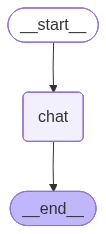

In [9]:
workflow = graph.compile(checkpointer=checkpointer)
workflow

#### Configs

In [10]:
def get_config(thread_id):
    return RunnableConfig(
        configurable={
            "thread_id": thread_id,
        },
        metadata={
            "thread_id": thread_id,
            "environment": os.getenv("APP_ENV", "default"),
            "app": "stm_postgres",
        },
        run_name="stm_postgres_turn",
    )

In [11]:
thread_id_I = str(uuid1())
config_I = get_config(thread_id=thread_id_I)

thread_id_II = str(uuid1())
config_II = get_config(thread_id=thread_id_II)

#### Execution

Thread I

In [12]:
workflow.invoke(
    {
        "messages": [
            HumanMessage(
                content="""
My name is pattagobi.
I live in Downtown, Verdansk.
My favorite food is cabbage.
"""
            ),
        ]
    },
    config=config_I,
)
final_state_I = workflow.invoke(
    {
        "messages": [
            HumanMessage(content="Without guessing, list every personal fact you know about me."),
        ]
    },
    config=config_I,
)


In [13]:
for message in final_state_I["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:

My name is pattagobi.
I live in Downtown, Verdansk.
My favorite food is cabbage.


LLM:
Hello Pattagobi! It's nice to learn a little about you.

So, you live in Downtown, Verdansk, and your favorite food is cabbage! That's a great and healthy choice.

Is there anything else you'd like to share or chat about?

Human:
Without guessing, list every personal fact you know about me.

LLM:
Based on our conversation, here are the personal facts I know about you:

*   Your name is Pattagobi.
*   You live in Downtown, Verdansk.
*   Your favorite food is cabbage.



Thread II

In [14]:
workflow.invoke(
    {
        "messages": [
            HumanMessage(
                content="""
My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA
"""
            ),
        ]
    },
    config=config_II,
)
final_state_II = workflow.invoke(
    {
        "messages": [
            HumanMessage(content="Without guessing, list every personal fact you know about me."),
        ]
    },
    config=config_II,
)


In [15]:
for message in final_state_II["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:

My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA


LLM:
Understood. I will remember the following:

*   **Name:** buh
*   **Occupation:** professional gaslighter at Lumon Industries
*   **Secret Code:** XQC-6767-BLUE-NEVLA

Human:
Without guessing, list every personal fact you know about me.

LLM:
Based on our previous conversation, I know the following personal facts about you:

1.  Your name is buh.
2.  You work as a professional gaslighter at Lumon Industries.
3.  Your secret code is XQC-6767-BLUE-NEVLA.



Close Context Manager

In [16]:
context_manager.__exit__(None, None, None)
console.print("Checkpointer closed successfully!")

Checkpointer closed successfully!


Load Memory

In [17]:
checkpointer_cm = get_checkpointer_context_manager(db_uri=DB_URI)
checkpointer = checkpointer_cm.__enter__()


In [18]:
workflow = graph.compile(checkpointer=checkpointer)
state_I = workflow.get_state(config=config_I)
state_II = workflow.get_state(config=config_II)

In [19]:
for message in state_I.values.get("messages", []):
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:

My name is pattagobi.
I live in Downtown, Verdansk.
My favorite food is cabbage.


LLM:
Hello Pattagobi! It's nice to learn a little about you.

So, you live in Downtown, Verdansk, and your favorite food is cabbage! That's a great and healthy choice.

Is there anything else you'd like to share or chat about?

Human:
Without guessing, list every personal fact you know about me.

LLM:
Based on our conversation, here are the personal facts I know about you:

*   Your name is Pattagobi.
*   You live in Downtown, Verdansk.
*   Your favorite food is cabbage.



In [20]:
for message in state_II.values.get("messages", []):
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:

My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA


LLM:
Understood. I will remember the following:

*   **Name:** buh
*   **Occupation:** professional gaslighter at Lumon Industries
*   **Secret Code:** XQC-6767-BLUE-NEVLA

Human:
Without guessing, list every personal fact you know about me.

LLM:
Based on our previous conversation, I know the following personal facts about you:

1.  Your name is buh.
2.  You work as a professional gaslighter at Lumon Industries.
3.  Your secret code is XQC-6767-BLUE-NEVLA.



Close Context Manager

In [21]:
checkpointer_cm.__exit__(None, None, None)
console.print("Checkpointer closed successfully!")

Checkpointer closed successfully!
